In [1]:
!pip install -q krippendorff scikit-learn pandas numpy matplotlib

In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import cohen_kappa_score, confusion_matrix, ConfusionMatrixDisplay
import krippendorff
import matplotlib.pyplot as plt
from itertools import combinations

In [3]:
a1 = pd.read_csv('annotated_tweets_1.csv')
a2 = pd.read_csv('tweets_for_annotation_2.csv')
a3 = pd.read_csv('annotated_tweets_3.csv')

print(f'File 1 columns: {list(a1.columns)}')
print(f'File 2 columns: {list(a2.columns)}')
print(f'File 3 columns: {list(a3.columns)}')
print(f'\nRows: {len(a1)}, {len(a2)}, {len(a3)}')

File 1 columns: ['tweet_id', 'athlete_display_name', 'raw_content', 'translated_content', 'annotator1_sentiment', 'annotator2_sentiment', 'annotator3_sentiment', 'final_sentiment', 'notes', 'annotation']
File 2 columns: ['tweet_id', 'athlete_display_name', 'raw_content', 'translated_content', 'annotator1_sentiment', 'annotator2_sentiment', 'annotator3_sentiment', 'final_sentiment', 'notes']
File 3 columns: ['tweet_id', 'athlete_display_name', 'raw_content', 'translated_content', 'annotator1_sentiment', 'annotator2_sentiment', 'annotator3_sentiment', 'final_sentiment', 'notes', 'annotation']

Rows: 498, 498, 498


In [4]:
LABEL_NORM = {
    'positive': 'positive', 'pos': 'positive', 'Pos': 'positive', 'Positive': 'positive',
    'negative': 'negative', 'neg': 'negative', 'Neg': 'negative', 'Negative': 'negative',
    'neutral': 'neutral', 'neu': 'neutral', 'Neu': 'neutral', 'Neutral': 'neutral'
}

df1 = a1[['tweet_id']].copy()
df1['annotator1'] = a1['annotation'].str.strip().map(LABEL_NORM)

df2 = a2[['tweet_id']].copy()
df2['annotator2'] = a2['annotator2_sentiment'].str.strip().map(LABEL_NORM)

df3 = a3[['tweet_id']].copy()
df3['annotator3'] = a3['annotation'].str.strip().map(LABEL_NORM)

df = df1.merge(df2, on='tweet_id').merge(df3, on='tweet_id')
print(f'Merged: {len(df)} tweets')

for col in ['annotator1', 'annotator2', 'annotator3']:
    unmapped = df[df[col].isna()]
    if len(unmapped) > 0:
        print(f'WARNING: {len(unmapped)} unmapped values in {col}')
        if col == 'annotator1':
            print(a1.loc[unmapped.index, 'annotation'].unique())
        elif col == 'annotator2':
            print(a2.loc[unmapped.index, 'annotator2_sentiment'].unique())
        else:
            print(a3.loc[unmapped.index, 'annotation'].unique())

df = df.dropna(subset=['annotator1', 'annotator2', 'annotator3'])
print(f'After dropping NaN: {len(df)} tweets')
df.head()

Merged: 498 tweets
After dropping NaN: 498 tweets


,tweet_id,annotator1,annotator2,annotator3
0,354907423514955779,positive,positive,positive
1,1454447935819706368,neutral,neutral,neutral
2,1672126327460343809,negative,negative,negative
3,1674072267943211009,negative,positive,negative
4,1673246782791520257,negative,negative,negative


In [5]:
LABEL_MAP = {'positive': 0, 'neutral': 1, 'negative': 2}
LABEL_NAMES = ['positive', 'neutral', 'negative']
annotators = ['annotator1', 'annotator2', 'annotator3']

df_num = df.copy()
for col in annotators:
    df_num[col + '_num'] = df_num[col].map(LABEL_MAP)

num_cols = [c + '_num' for c in annotators]

In [6]:
pairs = list(combinations(annotators, 2))
print('=== ALL PAIRWISE COHEN\'S KAPPA ===')
kappas = {}
for a, b in pairs:
    k = cohen_kappa_score(df[a], df[b])
    kappas[(a, b)] = k
    print(f'  {a} vs {b}: \u03ba = {k:.4f}')

avg_kappa = np.mean(list(kappas.values()))
print(f'\n  Average pairwise \u03ba = {avg_kappa:.4f}')

=== ALL PAIRWISE COHEN'S KAPPA ===
  annotator1 vs annotator2: κ = 0.5862
  annotator1 vs annotator3: κ = 0.6783
  annotator2 vs annotator3: κ = 0.5851

  Average pairwise κ = 0.6166


In [7]:
n_items = len(df_num)
n_raters = 3
n_categories = len(LABEL_MAP)

category_counts = np.zeros((n_items, n_categories), dtype=int)
for i in range(n_items):
    for col in num_cols:
        category_counts[i, int(df_num.iloc[i][col])] += 1

P_i = (1 / (n_raters * (n_raters - 1))) * (np.sum(category_counts ** 2, axis=1) - n_raters)
P_bar = np.mean(P_i)
p_j = np.sum(category_counts, axis=0) / (n_items * n_raters)
P_e_bar = np.sum(p_j ** 2)
fleiss_kappa = (P_bar - P_e_bar) / (1 - P_e_bar)

print(f'=== FLEISS\' KAPPA ===')
print(f'  \u03ba_Fleiss = {fleiss_kappa:.4f}')
print(f'  P_bar (observed) = {P_bar:.4f}')
print(f'  P_e_bar (expected) = {P_e_bar:.4f}')

=== FLEISS' KAPPA ===
  κ_Fleiss = 0.6155
  P_bar (observed) = 0.7697
  P_e_bar (expected) = 0.4012


In [8]:
reliability_data = df_num[num_cols].values.T
alpha = krippendorff.alpha(reliability_data=reliability_data, level_of_measurement='nominal')
print(f'=== KRIPPENDORFF\'S ALPHA ===')
print(f'  \u03b1 = {alpha:.4f}')

=== KRIPPENDORFF'S ALPHA ===
  α = 0.6157


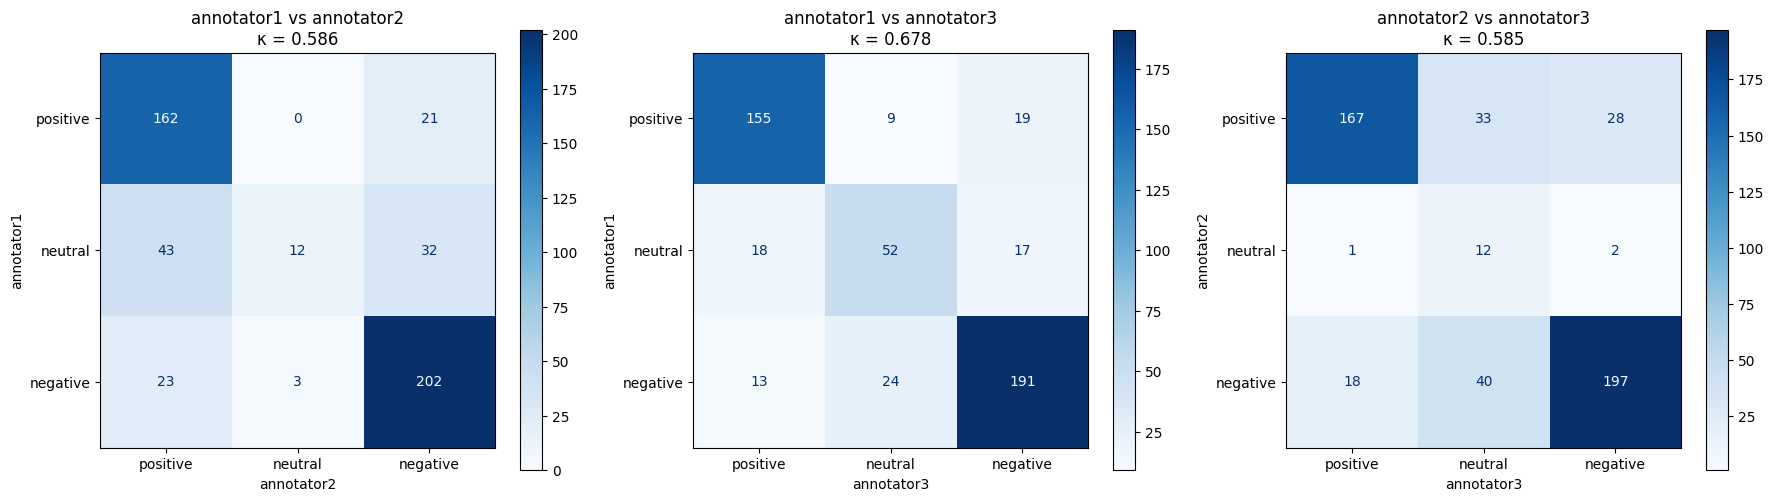

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (a, b) in enumerate(pairs):
    cm = confusion_matrix(df[a], df[b], labels=LABEL_NAMES)
    disp = ConfusionMatrixDisplay(cm, display_labels=LABEL_NAMES)
    disp.plot(ax=axes[idx], cmap='Blues', values_format='d')
    axes[idx].set_title(f'{a} vs {b}\n\u03ba = {kappas[(a,b)]:.3f}')
    axes[idx].set_xlabel(b)
    axes[idx].set_ylabel(a)
plt.tight_layout()
plt.savefig('fig_annotator_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
print('=== AGREEMENT BREAKDOWN BY CATEGORY ===')
for cat_name, cat_id in LABEL_MAP.items():
    full_agree = np.sum(category_counts[:, cat_id] == 3)
    majority = np.sum(category_counts[:, cat_id] >= 2)
    print(f'{cat_name}: full={full_agree}, majority={majority}')

full_agreement = np.sum(np.max(category_counts, axis=1) == 3)
majority_agreement = np.sum(np.max(category_counts, axis=1) >= 2)
no_majority = n_items - majority_agreement

print(f'\n=== SUMMARY ===')
print(f'Total tweets:            {n_items}')
print(f'Full agreement (3/3):    {full_agreement} ({100*full_agreement/n_items:.1f}%)')
print(f'Majority agreement (2/3):{majority_agreement - full_agreement} ({100*(majority_agreement-full_agreement)/n_items:.1f}%)')
print(f'No majority (ties):      {no_majority} ({100*no_majority/n_items:.1f}%)')
print(f'\nCohen \u03ba (pairwise avg): {avg_kappa:.3f}')
print(f'Fleiss \u03ba:                 {fleiss_kappa:.3f}')
print(f'Krippendorff \u03b1:          {alpha:.3f}')

=== AGREEMENT BREAKDOWN BY CATEGORY ===
positive: full=145, majority=194
neutral: full=10, majority=56
negative: full=176, majority=238

=== SUMMARY ===
Total tweets:            498
Full agreement (3/3):    331 (66.5%)
Majority agreement (2/3):157 (31.5%)
No majority (ties):      10 (2.0%)

Cohen κ (pairwise avg): 0.617
Fleiss κ:                 0.615
Krippendorff α:          0.616


In [11]:
results = {
    'metric': [
        'Cohen \u03ba (A1-A2)', 'Cohen \u03ba (A1-A3)', 'Cohen \u03ba (A2-A3)',
        'Cohen \u03ba (avg)', 'Fleiss \u03ba', 'Krippendorff \u03b1',
        'Raw agreement (3/3)', 'Majority agreement'
    ],
    'value': [
        f'{list(kappas.values())[0]:.3f}', f'{list(kappas.values())[1]:.3f}',
        f'{list(kappas.values())[2]:.3f}', f'{avg_kappa:.3f}',
        f'{fleiss_kappa:.3f}', f'{alpha:.3f}',
        f'{100*full_agreement/n_items:.1f}%', f'{100*majority_agreement/n_items:.1f}%'
    ]
}
pd.DataFrame(results).to_csv('agreement_results.csv', index=False)
pd.DataFrame(results)

,metric,value
0,Cohen κ (A1-A2),0.586
1,Cohen κ (A1-A3),0.678
2,Cohen κ (A2-A3),0.585
3,Cohen κ (avg),0.617
4,Fleiss κ,0.615
5,Krippendorff α,0.616
6,Raw agreement (3/3),66.5%
7,Majority agreement,98.0%
